# Notebook 10 - Análisis de residuos y monitorización operativa

## Motivación
Hasta ahora el error ha sido tratado como métrica de evaluación.
Este notebook lo convierte en una **senal del sistema** que permite
monitorizar el comportamiento real de la planta.

*Si el modelo es bueno y la planta funciona correctamente, el residuo
deberia ser pequeno, simétrico y sin tendencia. Si el residuo crece,
se sesga o muestra patrones, algo ha cambiado: suciedad, degradación o
fallo parcial.*

## Definición formal del residuo

```
e(t)     = P(t) - P_hat(t)           # Error absoluto (kW)
e_rel(t) = (P(t) - P_hat(t)) / P(t)  # Error relativo (solo horas de luz)
```

**Convenio:** `e(t) > 0` la planta produce más de lo esperado (subestimación);
`e(t) < 0` la planta produce menos de lo esperado (sobreestimación).

## Flujo del notebook
1. Configuracion de rutas y carga de datos
2. Cálculo de residuos y estadísticos descriptivos
3. Distribución del error
4. Tests formales de normalidad
5. Gráfico Q-Q
6. Autocorrelación (ACF + Ljung-Box)
7. Evolución temporal del residuo
8. MAE y bias diario
9. Error por condición operativa
10. Análisis estacional
11. Correlación con variables externas
12. Monitor operativo
13. Clasificación y zoom de episodios anómalos
14. Perfil diario: anómalo vs. normal
15. Guardado de resultados


### 1. Configuración de rutas e importaciones


In [1]:
import json
import os
import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import scipy.stats as stats
from scipy.stats import kruskal
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.nonparametric.smoothers_lowess import lowess
from statsmodels.stats.diagnostic import acorr_ljungbox

current = Path().resolve()
root = current.anchor
while not ((current / "data").exists() and (current / "src").exists()):
    if str(current) == root:
        raise FileNotFoundError(
            "No se encontro la raíz del proyecto. "
            "Asegurate de que existen las carpetas data/ y src/."
        )
    current = current.parent

os.chdir(current)
if str(current) not in sys.path:
    sys.path.insert(0, str(current))

PROJECT_ROOT = current
DATA_DIR    = PROJECT_ROOT / "data"
RESULTS_DIR = DATA_DIR / "results"
SPLITS_DIR  = DATA_DIR / "splits"
MODELS_DIR  = DATA_DIR / "models"

from src.evaluation import compute_metrics

BLUE   = "steelblue"
RED    = "tomato"
GREEN  = "seagreen"
ORANGE = "darkorange"
GRAY   = "#888888"
SEASON_COLORS = {
    "Invierno": "#4C72B0", "Primavera": "#55A868",
    "Verano":   "#C44E52", "Otono":     "#DD8452",
}

warnings.filterwarnings("ignore")
print(f"Raíz del proyecto: {PROJECT_ROOT.name}")


Raíz del proyecto: TFM_RPUEBAS


### 2. Carga del conjunto de test y del modelo
Por defecto se carga el MLP. Si no existe se usa el primer modelo disponible.


In [2]:
test_df = pd.read_csv(SPLITS_DIR / "test.csv", parse_dates=["timestamp"])

with open(SPLITS_DIR / "feature_cols.json", encoding="utf-8") as f:
    FEATURE_COLS = json.load(f)

TARGET        = "power_pu"
NOMINAL_LECA1 = 19.53  # kW

model_path = MODELS_DIR / "MLP.pkl"
if not model_path.exists():
    candidates = list(MODELS_DIR.glob("*.pkl")) + list(MODELS_DIR.glob("*.joblib"))
    if not candidates:
        raise FileNotFoundError(
            "No se encontro ningún modelo en data/models/. "
            "Ejecuta primero el notebook 03."
        )
    model_path = candidates[0]

model      = joblib.load(model_path)
model_name = model_path.stem
y_pred     = model.predict(test_df[FEATURE_COLS])

print(f"Modelo cargado: {model_name}")
print(f"Test: {test_df.shape} | "
      f"{test_df['timestamp'].min().date()} -> {test_df['timestamp'].max().date()}")


Modelo cargado: MLP
Test: (8639, 37) | 2024-03-01 -> 2024-05-30


### 3. Calculo de residuos y estadísticos descriptivos


In [3]:
df_res = test_df[["timestamp", "power_pu", "radiation", "T_ambiente", "hour", "month"]].copy()
df_res["y_pred"]      = y_pred
df_res["e_pu"]        = df_res["power_pu"] - df_res["y_pred"]
df_res["e_kw"]        = df_res["e_pu"] * NOMINAL_LECA1
df_res["e_abs_kw"]    = df_res["e_kw"].abs()
df_res["is_daylight"] = df_res["power_pu"] > 0.01
df_res["e_rel"] = np.where(
    df_res["is_daylight"],
    df_res["e_pu"] / (df_res["power_pu"] + 1e-6),
    np.nan,
)

def get_season(m):
    if m in [12, 1, 2]:  return "Invierno"
    if m in [3, 4, 5]:   return "Primavera"
    if m in [6, 7, 8]:   return "Verano"
    return "Otono"

df_res["season"] = df_res["month"].apply(get_season)
df_day = df_res[df_res["is_daylight"]]

s  = df_res["e_kw"].describe()
sd = df_day["e_kw"].describe()
print("Residuo conjunto completo:")
print("  Bias: {:+.4f} kW | Std: {:.4f} kW | RMSE: {:.4f} kW".format(
    s["mean"], s["std"], float(np.sqrt((df_res["e_kw"]**2).mean()))))
print("Residuo horas de producción:")
print("  Bias: {:+.4f} kW | MAE: {:.4f} kW | RMSE: {:.4f} kW".format(
    sd["mean"], df_day["e_abs_kw"].mean(), float(np.sqrt((df_day["e_kw"]**2).mean()))))
print("  Error relativo medio: {:.2%}".format(df_day["e_rel"].mean()))
print("  % registros |e|>1kW: {:.1%}".format((df_day["e_abs_kw"] > 1).mean()))


Residuo conjunto completo:
  Bias: +0.0714 kW | Std: 0.8533 kW | RMSE: 0.8563 kW
Residuo horas de producción:
  Bias: +0.1405 kW | MAE: 0.6060 kW | RMSE: 1.1850 kW
  Error relativo medio: -1.86%
  % registros |e|>1kW: 15.6%


### 4. Distribución del error
Histograma del error absoluto (kW) y relativo con curva normal superpuesta.


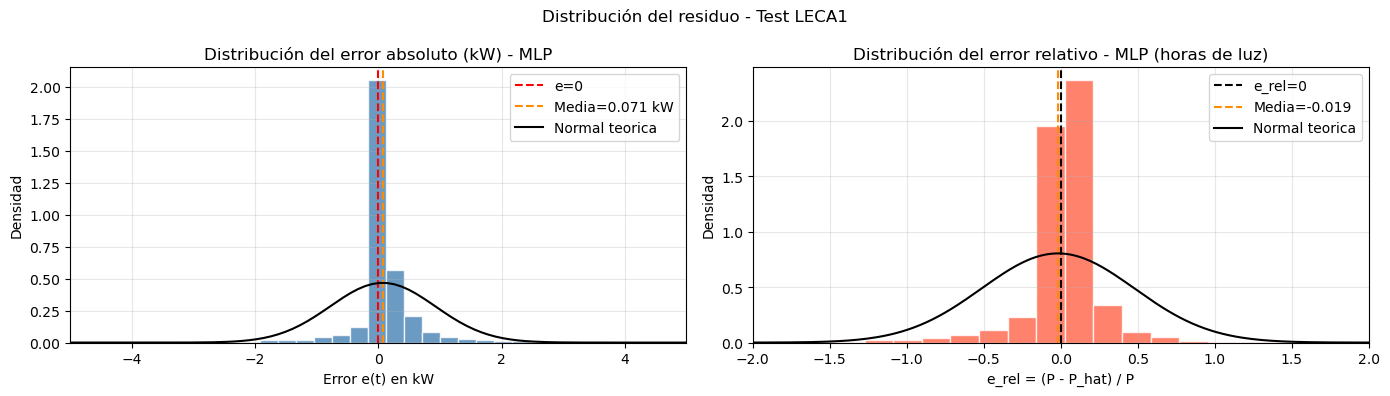

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(df_res["e_kw"], bins=80, color=BLUE, edgecolor="white", alpha=0.8, density=True)
ax.axvline(0, color="red", linestyle="--", lw=1.5, label="e=0")
ax.axvline(df_res["e_kw"].mean(), color=ORANGE, linestyle="--", lw=1.5,
           label="Media={:.3f} kW".format(df_res["e_kw"].mean()))
mu, sigma = df_res["e_kw"].mean(), df_res["e_kw"].std()
xr = np.linspace(df_res["e_kw"].min(), df_res["e_kw"].max(), 200)
ax.plot(xr, stats.norm.pdf(xr, mu, sigma), "k-", lw=1.5, label="Normal teorica")
ax.set_title("Distribución del error absoluto (kW) - {}".format(model_name))
ax.set_xlabel("Error e(t) en kW"); ax.set_ylabel("Densidad")
ax.set_xlim(-5, 5); ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
df_dl = df_res[df_res["is_daylight"]].dropna(subset=["e_rel"])
ax.hist(df_dl["e_rel"], bins=80, color=RED, edgecolor="white", alpha=0.8, density=True)
ax.axvline(0, color="black", linestyle="--", lw=1.5, label="e_rel=0")
mu_r, sigma_r = df_dl["e_rel"].mean(), df_dl["e_rel"].std()
ax.axvline(mu_r, color=ORANGE, linestyle="--", lw=1.5,
           label="Media={:.3f}".format(mu_r))
xrr = np.linspace(-2, 2, 200)
ax.plot(xrr, stats.norm.pdf(xrr, mu_r, sigma_r), "k-", lw=1.5, label="Normal teorica")
ax.set_xlim(-2, 2)
ax.set_title("Distribución del error relativo - {} (horas de luz)".format(model_name))
ax.set_xlabel("e_rel = (P - P_hat) / P"); ax.set_ylabel("Densidad")
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Distribución del residuo - Test LECA1", fontsize=12)
plt.tight_layout()
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(RESULTS_DIR / "residuo_distribucion.png", dpi=150, bbox_inches="tight")
plt.show()


### 5. Tests formales de normalidad
En muestras grandes los tests siempre rechazan la normalidad estricta.
Lo relevante es interpretar la asimetría y la curtosis.


In [6]:
e_day = df_dl["e_kw"].dropna().values
e_day_norm = (e_day - e_day.mean()) / e_day.std()

np.random.seed(42)
muestra = np.random.choice(e_day, size=min(5000, len(e_day)), replace=False)
muestra_norm = (muestra - muestra.mean()) / muestra.std()

stat_sw, p_sw = stats.shapiro(muestra_norm)
stat_ks, p_ks = stats.kstest(e_day_norm, "norm")
stat_dp, p_dp = stats.normaltest(e_day)
skewness = stats.skew(e_day)
kurtosis = stats.kurtosis(e_day)
alpha = 0.05

print("N (horas de luz): {:,}\n".format(len(e_day)))
print("{:<30} {:>12} {:>14} {:>22}".format("Test", "Estadistico", "p-valor", "Conclusion"))
print("-" * 82)
for nombre, stat, p in [
    ("Shapiro-Wilk (n=5000)", stat_sw, p_sw),
    ("Kolmogorov-Smirnov",    stat_ks, p_ks),
    ("D'Agostino-Pearson",    stat_dp, p_dp),
]:
    concl = "No rechaza H0" if p > alpha else "Rechaza H0"
    print("{:<30} {:>12.4f} {:>14.4e} {:>22}".format(nombre, stat, p, concl))

print("\nAsimetría (skewness): {:.4f}  (|sk|<0.5 aprox. simetrico)".format(skewness))
print("Curtosis (exceso):    {:.4f}  (>0 colas pesadas)".format(kurtosis))
sym = "aproximadamente simétrica" if abs(skewness) < 0.5 else "con asimetria notable"
print("\nLa distribución es {}.".format(sym))
if kurtosis > 1:
    print("Colas más pesadas que la normal: errores grandes más frecuentes de lo esperado.")
print("Los tests formales rechazan normalidad estricta en muestras grandes.")


N (horas de luz): 4,469

Test                            Estadistico        p-valor             Conclusion
----------------------------------------------------------------------------------
Shapiro-Wilk (n=5000)                0.6554     8.6949e-70             Rechaza H0
Kolmogorov-Smirnov                   0.2138    7.8078e-180             Rechaza H0
D'Agostino-Pearson                3515.4814     0.0000e+00             Rechaza H0

Asimetría (skewness): -3.1948  (|sk|<0.5 aprox. simetrico)
Curtosis (exceso):    36.4134  (>0 colas pesadas)

La distribución es con asimetria notable.
Colas más pesadas que la normal: errores grandes más frecuentes de lo esperado.
Los tests formales rechazan normalidad estricta en muestras grandes.


### 6. Gráfico Q-Q
Compara cuantiles observados con cuantiles normales teóricos.
Desviaciones en las colas indican errores extremos más frecuentes de lo esperado.


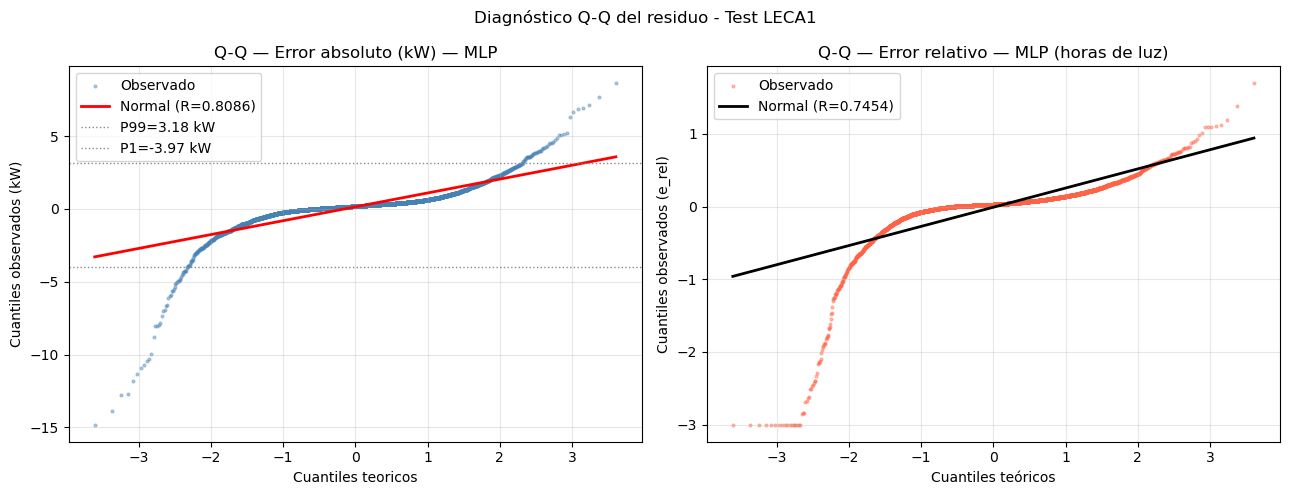

Q-Q error absoluto R=0.8086 | error relativo R=0.7454
P99=3.178 kW (16.3% nominal) | P1=-3.972 kW


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
(osm, osr), (slope, intercept, r) = stats.probplot(e_day, dist="norm", plot=None)
ax.scatter(osm, osr, s=4, alpha=0.4, color=BLUE, label="Observado")
xl = np.array([osm.min(), osm.max()])
ax.plot(xl, slope * xl + intercept, "r-", lw=2, label="Normal (R={:.4f})".format(r))
p99, p1 = np.percentile(e_day, 99), np.percentile(e_day, 1)
ax.axhline(p99, color=GRAY, linestyle=":", lw=1, label="P99={:.2f} kW".format(p99))
ax.axhline(p1,  color=GRAY, linestyle=":", lw=1, label="P1={:.2f} kW".format(p1))
ax.set_title("Q-Q — Error absoluto (kW) — {}".format(model_name))
ax.set_xlabel("Cuantiles teoricos"); ax.set_ylabel("Cuantiles observados (kW)")
ax.legend(); ax.grid(alpha=0.3)

ax = axes[1]
e_rel_c = df_dl["e_rel"].dropna().clip(-3, 3).values
(osm_r, osr_r), (slope_r, intercept_r, r_r) = stats.probplot(e_rel_c, dist="norm", plot=None)
ax.scatter(osm_r, osr_r, s=4, alpha=0.4, color=RED, label="Observado")
xl_r = np.array([osm_r.min(), osm_r.max()])
ax.plot(xl_r, slope_r * xl_r + intercept_r, "k-", lw=2, label="Normal (R={:.4f})".format(r_r))
ax.set_title("Q-Q — Error relativo — {} (horas de luz)".format(model_name))
ax.set_xlabel("Cuantiles teóricos"); ax.set_ylabel("Cuantiles observados (e_rel)")
ax.legend(); ax.grid(alpha=0.3)

plt.suptitle("Diagnóstico Q-Q del residuo - Test LECA1", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residuo_qq.png", dpi=150, bbox_inches="tight")
plt.show()
print("Q-Q error absoluto R={:.4f} | error relativo R={:.4f}".format(r, r_r))
print("P99={:.3f} kW ({:.1f}% nominal) | P1={:.3f} kW".format(
      p99, p99/NOMINAL_LECA1*100, p1))


### 7. Autocorrelación del residuo (ACF + Test de Ljung-Box)
Si el residuo fuera ruido blanco, la ACF debería tener todos los retardos
dentro de las bandas de confianza al 95%.


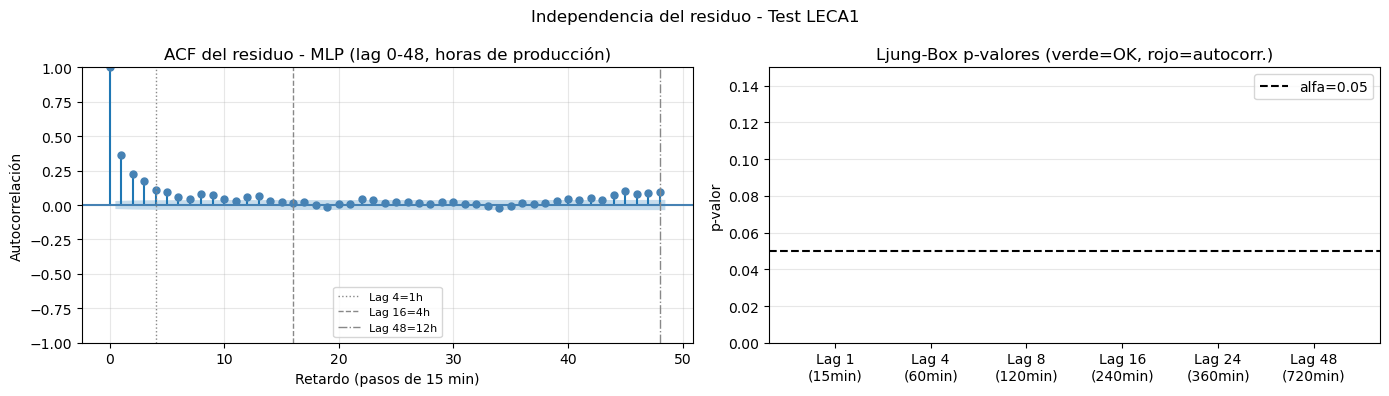

   Lag    Tiempo    Estadístico        p-valor  Conclusion               
---------------------------------------------------------------------------
     1      15min        587.883    7.2357e-130  Autocorr. significativa  
     4      60min        999.033    5.7834e-215  Autocorr. significativa  
     8     120min       1089.460    7.2357e-230  Autocorr. significativa  
    16     240min       1165.512    3.7461e-238  Autocorr. significativa  
    24     360min       1183.057    1.0028e-234  Autocorr. significativa  
    48     720min       1413.829    1.3436e-264  Autocorr. significativa  

Retardos con autocorrelación significativa: 6 de 6
Autocorrelación persistente: considerar lags adicionales.


In [8]:
e_series = df_res[df_res["is_daylight"]].sort_values("timestamp")["e_kw"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(e_series, lags=48, alpha=0.05, ax=axes[0], color=BLUE)
axes[0].set_title("ACF del residuo - {} (lag 0-48, horas de producción)".format(model_name))
axes[0].set_xlabel("Retardo (pasos de 15 min)")
axes[0].set_ylabel("Autocorrelación")
for lag, ls, lbl in [(4,":", "1h"), (16,"--","4h"), (48,"-.","12h")]:
    axes[0].axvline(lag, color=GRAY, linestyle=ls, lw=1, label="Lag {}={}".format(lag, lbl))
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

lags_test = [1, 4, 8, 16, 24, 48]
lb = acorr_ljungbox(e_series, lags=lags_test, return_df=True)
axes[1].bar(range(len(lags_test)), lb["lb_pvalue"],
            color=[GREEN if p > 0.05 else RED for p in lb["lb_pvalue"]],
            alpha=0.8, edgecolor="white")
axes[1].axhline(0.05, color="black", linestyle="--", lw=1.5, label="alfa=0.05")
axes[1].set_xticks(range(len(lags_test)))
axes[1].set_xticklabels(["Lag {}\n({}min)".format(l, l*15) for l in lags_test])
axes[1].set_ylabel("p-valor")
axes[1].set_title("Ljung-Box p-valores (verde=OK, rojo=autocorr.)")
axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")
axes[1].set_ylim(0, max(lb["lb_pvalue"].max() * 1.2, 0.15))

plt.suptitle("Independencia del residuo - Test LECA1", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residuo_acf_ljungbox.png", dpi=150, bbox_inches="tight")
plt.show()

print("{:>6}  {:>8}  {:>13}  {:>13}  {:<25}".format(
      "Lag", "Tiempo", "Estadístico", "p-valor", "Conclusion"))
print("-" * 75)
for lag, row in zip(lags_test, lb.itertuples()):
    concl = "Sin autocorr." if row.lb_pvalue > 0.05 else "Autocorr. significativa"
    print("{:>6}  {:>6}min  {:>13.3f}  {:>13.4e}  {:<25}".format(
          lag, lag*15, row.lb_stat, row.lb_pvalue, concl))

n_sig = (lb["lb_pvalue"] < 0.05).sum()
print("\nRetardos con autocorrelación significativa: {} de {}".format(n_sig, len(lags_test)))
if n_sig == 0:
    print("El residuo se comporta como ruido blanco.")
elif n_sig <= 2:
    print("Autocorrelación residual leve a corto plazo.")
else:
    print("Autocorrelación persistente: considerar lags adicionales.")


### 8. Evolucón temporal del residuo
Error bruto y suavizado (4h), error relativo diurno y error acumulado.


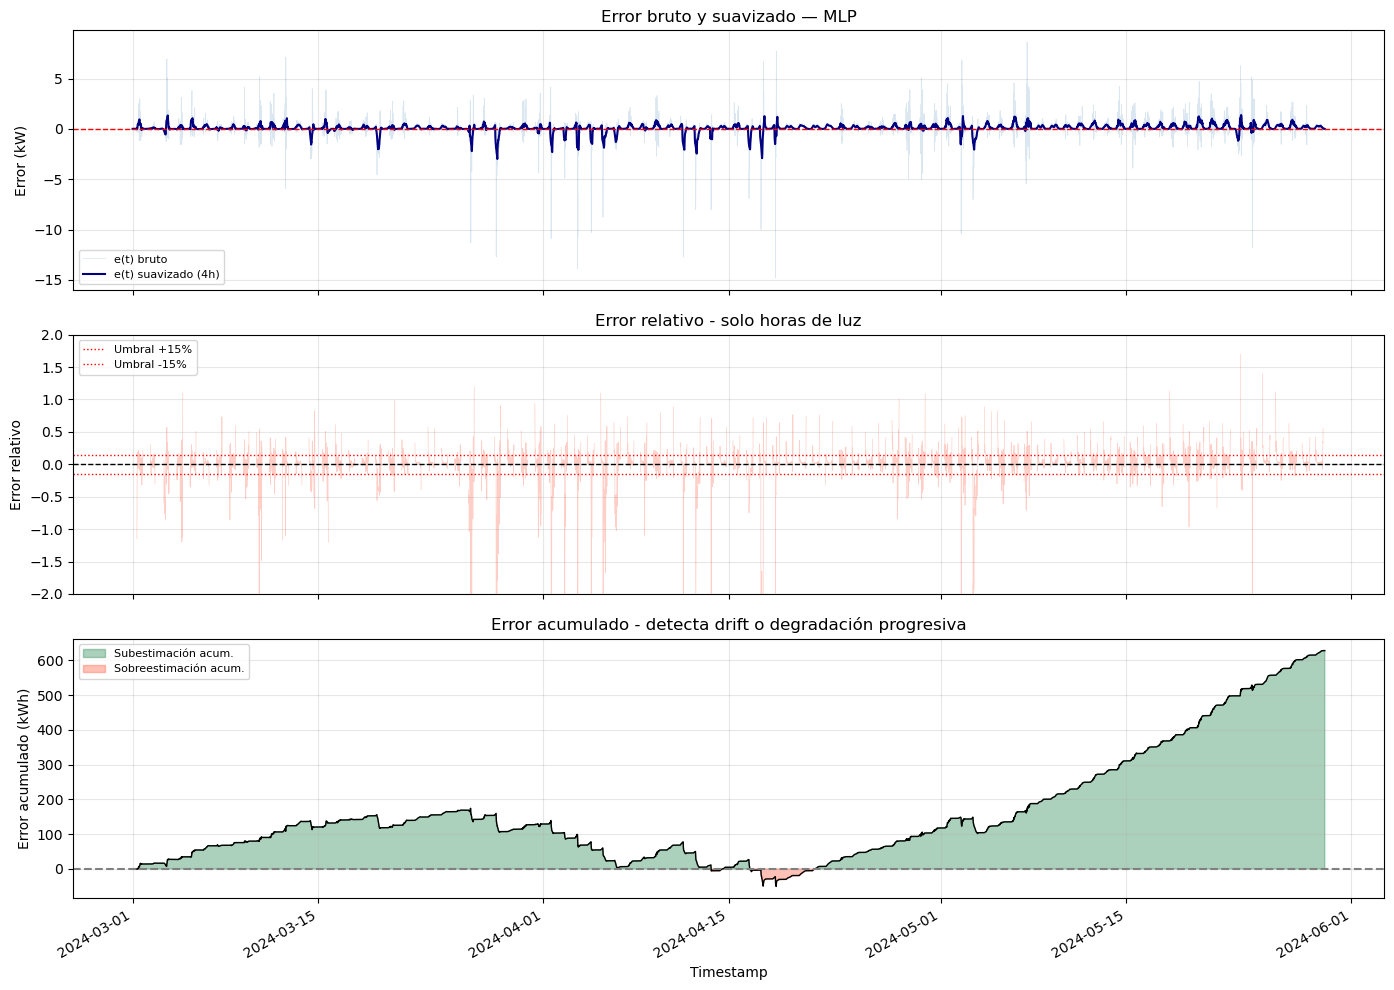

In [9]:
df_res = df_res.sort_values("timestamp").copy()
df_res["e_kw_smooth"]   = df_res["e_kw"].rolling(window=16, center=True, min_periods=4).mean()
df_res["e_kw_daylight"] = df_res["e_kw"].where(df_res["is_daylight"], other=0)
df_res["e_kw_cum"]      = df_res["e_kw_daylight"].cumsum()

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

axes[0].plot(df_res["timestamp"], df_res["e_kw"],
             alpha=0.2, color=BLUE, lw=0.5, label="e(t) bruto")
axes[0].plot(df_res["timestamp"], df_res["e_kw_smooth"],
             color="navy", lw=1.5, label="e(t) suavizado (4h)")
axes[0].axhline(0, color="red", linestyle="--", lw=1)
axes[0].set_ylabel("Error (kW)"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[0].set_title("Error bruto y suavizado — {}".format(model_name))

axes[1].plot(df_res["timestamp"], df_res["e_rel"], alpha=0.3, color=RED, lw=0.5)
axes[1].axhline(0, color="black", linestyle="--", lw=1)
axes[1].axhline( 0.15, color="red", linestyle=":", lw=1, label="Umbral +15%")
axes[1].axhline(-0.15, color="red", linestyle=":", lw=1, label="Umbral -15%")
axes[1].set_ylim(-2, 2); axes[1].set_ylabel("Error relativo")
axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3)
axes[1].set_title("Error relativo - solo horas de luz")

axes[2].fill_between(df_res["timestamp"], df_res["e_kw_cum"], 0,
    where=df_res["e_kw_cum"] > 0, alpha=0.4, color=GREEN, label="Subestimación acum.")
axes[2].fill_between(df_res["timestamp"], df_res["e_kw_cum"], 0,
    where=df_res["e_kw_cum"] <= 0, alpha=0.4, color=RED, label="Sobreestimación acum.")
axes[2].plot(df_res["timestamp"], df_res["e_kw_cum"], color="black", lw=1)
axes[2].axhline(0, color="gray", linestyle="--")
axes[2].set_ylabel("Error acumulado (kWh)")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)
axes[2].set_title("Error acumulado - detecta drift o degradación progresiva")

plt.xlabel("Timestamp"); fig.autofmt_xdate()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residuo_temporal.png", dpi=150, bbox_inches="tight")
plt.show()


### 9. MAE y bias diario


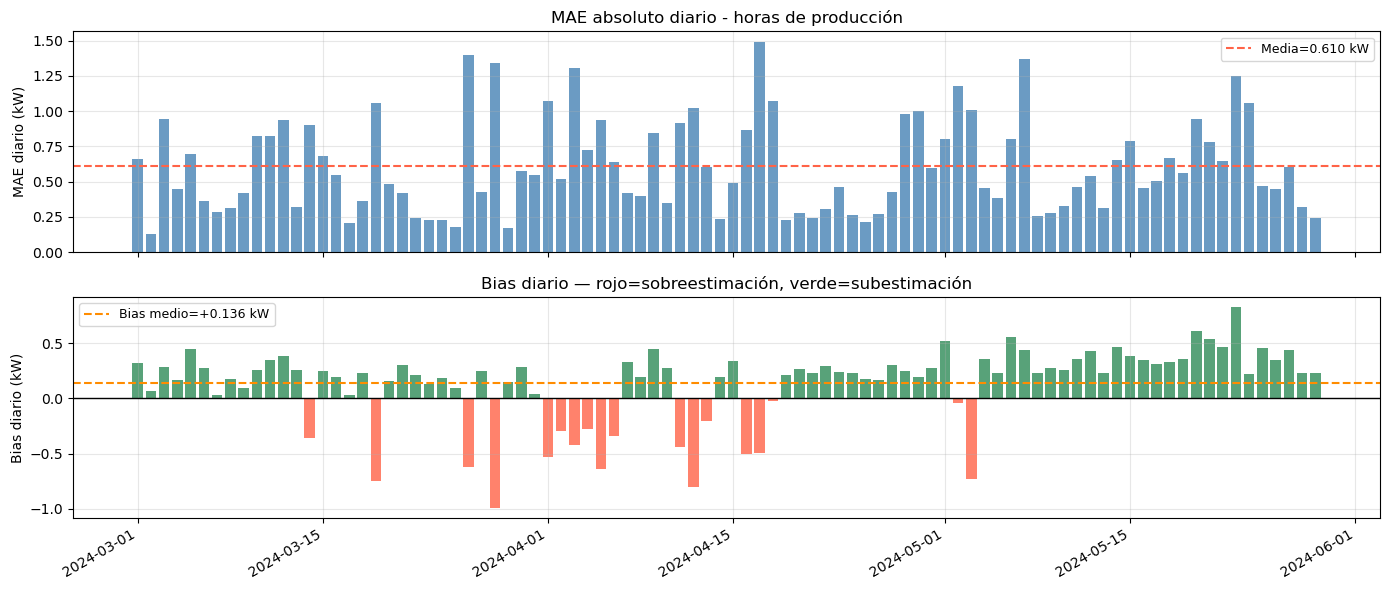

MAE diario medio:  0.610 kW
MAE diario máximo: 1.492 kW  (dia 2024-04-17)
Dias con bias > 0: 72 de 90


In [12]:
df_res["date"] = df_res["timestamp"].dt.date

daily = df_res[df_res["is_daylight"]].groupby("date").agg(
    MAE_kw=("e_abs_kw", "mean"),
    bias_kw=("e_kw", "mean"),
    n=("e_kw", "count"),
).reset_index()
daily["date"] = pd.to_datetime(daily["date"])

fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)

axes[0].bar(daily["date"], daily["MAE_kw"], color=BLUE, alpha=0.8, width=0.8)
axes[0].axhline(daily["MAE_kw"].mean(), color=RED, linestyle="--", lw=1.5,
                label="Media={:.3f} kW".format(daily["MAE_kw"].mean()))
axes[0].set_ylabel("MAE diario (kW)"); axes[0].grid(alpha=0.3)
axes[0].set_title("MAE absoluto diario - horas de producción"); axes[0].legend(fontsize=9)

axes[1].bar(daily["date"], daily["bias_kw"],
            color=[RED if v < 0 else GREEN for v in daily["bias_kw"]],
            alpha=0.8, width=0.8)
axes[1].axhline(0, color="black", lw=1)
axes[1].axhline(daily["bias_kw"].mean(), color=ORANGE, linestyle="--", lw=1.5,
                label="Bias medio={:+.3f} kW".format(daily["bias_kw"].mean()))
axes[1].set_ylabel("Bias diario (kW)"); axes[1].grid(alpha=0.3)
axes[1].set_title("Bias diario — rojo=sobreestimación, verde=subestimación")
axes[1].legend(fontsize=9)

fig.autofmt_xdate(); plt.tight_layout()
plt.savefig(RESULTS_DIR / "residuo_mae_diario.png", dpi=150, bbox_inches="tight")
plt.show()

dia_max = daily.loc[daily["MAE_kw"].idxmax(), "date"].date()
print("MAE diario medio:  {:.3f} kW".format(daily["MAE_kw"].mean()))
print("MAE diario máximo: {:.3f} kW  (dia {})".format(daily["MAE_kw"].max(), dia_max))
print("Dias con bias > 0: {} de {}".format((daily["bias_kw"] > 0).sum(), len(daily)))


### 10. Error por condición operativa (hora e irradiancia)


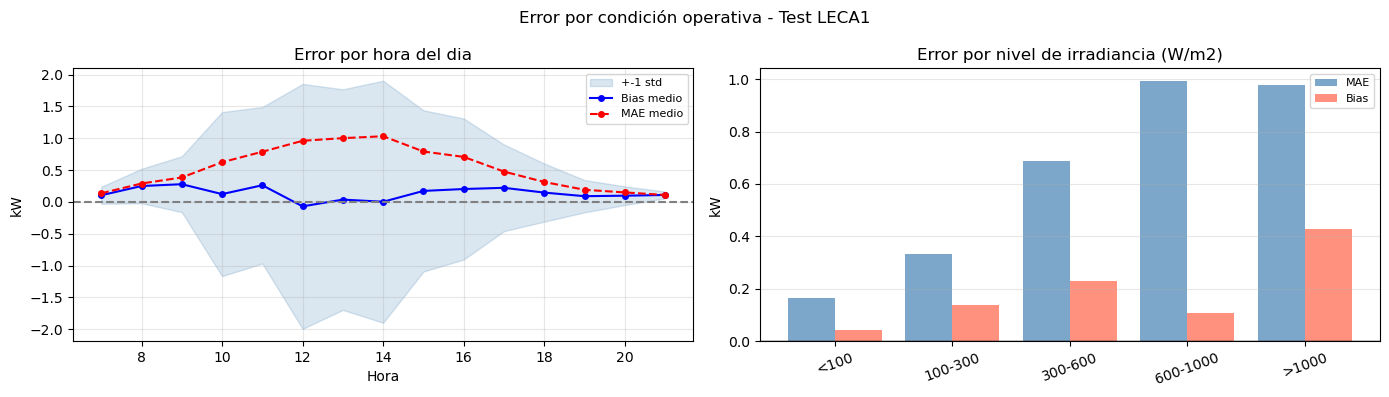

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly = df_res[df_res["is_daylight"]].groupby("hour").agg(
    MAE=("e_abs_kw", "mean"), bias=("e_kw", "mean"), std=("e_kw", "std")
)
axes[0].fill_between(hourly.index,
    hourly["bias"] - hourly["std"], hourly["bias"] + hourly["std"],
    alpha=0.2, color=BLUE, label="+-1 std")
axes[0].plot(hourly.index, hourly["bias"], "b-o", ms=4, label="Bias medio")
axes[0].plot(hourly.index, hourly["MAE"],  "r--o", ms=4, label="MAE medio")
axes[0].axhline(0, color="gray", linestyle="--")
axes[0].set_title("Error por hora del dia")
axes[0].set_xlabel("Hora"); axes[0].set_ylabel("kW")
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)

bins_r   = [0, 100, 300, 600, 1000, 2000]
labels_r = ["<100", "100-300", "300-600", "600-1000", ">1000"]
df_res["rad_bin"] = pd.cut(df_res["radiation"], bins=bins_r, labels=labels_r)
rad_seg = df_res[df_res["is_daylight"]].groupby("rad_bin", observed=True).agg(
    MAE=("e_abs_kw", "mean"), bias=("e_kw", "mean")
)
x = range(len(rad_seg))
axes[1].bar(x, rad_seg["MAE"],  color=BLUE, alpha=0.7, label="MAE",  width=0.4, align="edge")
axes[1].bar([xi+0.4 for xi in x], rad_seg["bias"], color=RED, alpha=0.7,
            label="Bias", width=0.4, align="edge")
axes[1].set_xticks([xi+0.4 for xi in x])
axes[1].set_xticklabels(rad_seg.index, rotation=20)
axes[1].axhline(0, color="black", lw=1)
axes[1].set_title("Error por nivel de irradiancia (W/m2)")
axes[1].set_ylabel("kW"); axes[1].legend(fontsize=8); axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("Error por condición operativa - Test LECA1", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residuo_por_condicion.png", dpi=150, bbox_inches="tight")
plt.show()


### 11. Análisis estacional del residuo


Estacion      MAE (kW)   Bias (kW)   RMSE (kW)       Std         N
-----------------------------------------------------------------
Invierno           ---         ---         ---       ---         0
Primavera        0.606      +0.140       1.185     1.177     4,469
Verano             ---         ---         ---       ---         0
Otono              ---         ---         ---       ---         0


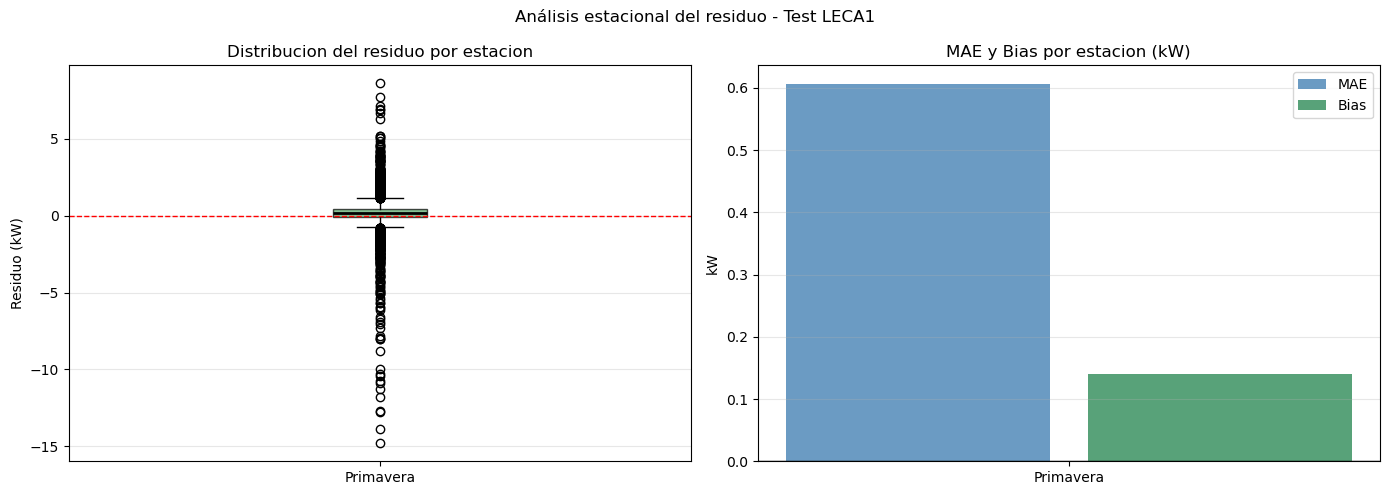

Insuficientes estaciones con datos para Kruskal-Wallis.


In [14]:
season_order = ["Invierno", "Primavera", "Verano", "Otono"]
df_day_s = df_res[df_res["is_daylight"]].copy()

season_stats = (
    df_day_s.groupby("season")
    .agg(
        MAE=(  "e_abs_kw", "mean"),
        bias=( "e_kw",     "mean"),
        std=(  "e_kw",     "std"),
        RMSE=( "e_kw",     lambda x: float(np.sqrt((x**2).mean()))),
        n=(    "e_kw",     "count"),
    )
    .reindex(season_order)
)

print("{:<12}  {:>8}  {:>10}  {:>10}  {:>8}  {:>8}".format(
      "Estacion", "MAE (kW)", "Bias (kW)", "RMSE (kW)", "Std", "N"))
print("-" * 65)
for s, row in season_stats.iterrows():
    if pd.isna(row["n"]):
        print("{:<12}  {:>8}  {:>10}  {:>10}  {:>8}  {:>8}".format(
              s, "---", "---", "---", "---", "0"))
    else:
        print("{:<12}  {:>8.3f}  {:>+10.3f}  {:>10.3f}  {:>8.3f}  {:>8,}".format(
              s, float(row["MAE"]), float(row["bias"]),
              float(row["RMSE"]), float(row["std"]), int(row["n"])))

valid_mae = season_stats["MAE"].dropna()
if len(valid_mae) > 1:
    print("\nMayor error: {} ({:.3f} kW)".format(valid_mae.idxmax(), valid_mae.max()))
    print("Menor error: {} ({:.3f} kW)".format(valid_mae.idxmin(), valid_mae.min()))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

data_box, valid_seasons = [], []
for s in season_order:
    vals = df_day_s[df_day_s["season"] == s]["e_kw"].dropna().values
    if len(vals) > 0:
        data_box.append(vals); valid_seasons.append(s)

if data_box:
    bp = axes[0].boxplot(data_box, labels=valid_seasons, patch_artist=True,
                         medianprops=dict(color="black", lw=2))
    for patch, s in zip(bp["boxes"], valid_seasons):
        patch.set_facecolor(SEASON_COLORS.get(s, GRAY)); patch.set_alpha(0.7)
axes[0].axhline(0, color="red", linestyle="--", lw=1)
axes[0].set_title("Distribucion del residuo por estacion")
axes[0].set_ylabel("Residuo (kW)"); axes[0].grid(alpha=0.3, axis="y")

valid_stats = season_stats.dropna()
if not valid_stats.empty:
    xv = range(len(valid_stats))
    axes[1].bar([xi-0.2 for xi in xv], valid_stats["MAE"],  width=0.35,
                color=BLUE, alpha=0.8, label="MAE")
    axes[1].bar([xi+0.2 for xi in xv], valid_stats["bias"], width=0.35,
                color=[RED if v < 0 else GREEN for v in valid_stats["bias"]],
                alpha=0.8, label="Bias")
    axes[1].set_xticks(list(xv)); axes[1].set_xticklabels(valid_stats.index)
    axes[1].axhline(0, color="black", lw=1)
    axes[1].set_title("MAE y Bias por estacion (kW)")
    axes[1].set_ylabel("kW"); axes[1].legend(); axes[1].grid(alpha=0.3, axis="y")

plt.suptitle("Análisis estacional del residuo - Test LECA1", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residuo_estacional.png", dpi=150, bbox_inches="tight")
plt.show()

if len(data_box) >= 2:
    stat_kw, p_kw = kruskal(*data_box)
    print("\nKruskal-Wallis: H={:.3f}, p={:.4e}".format(stat_kw, p_kw))
    print("Diferencias significativas." if p_kw < 0.05 else "Sin diferencias significativas (p>0.05).")
else:
    print("Insuficientes estaciones con datos para Kruskal-Wallis.")


### 12. Correlación del residuo con variables externas
|r| > 0.20 indica que el modelo no captura completamente esa variable.
La curva LOWESS detecta relaciones no lineales.


Variable                         Pearson r        p-valor   Spearman rho
------------------------------------------------------------------------
Irradiancia (W/m2)                 -0.0000     9.9861e-01         0.2164
Temperatura ambiente (C)           -0.0047     7.5245e-01         0.0906
Producción real (p.u.)              0.2923     9.9186e-89         0.4212


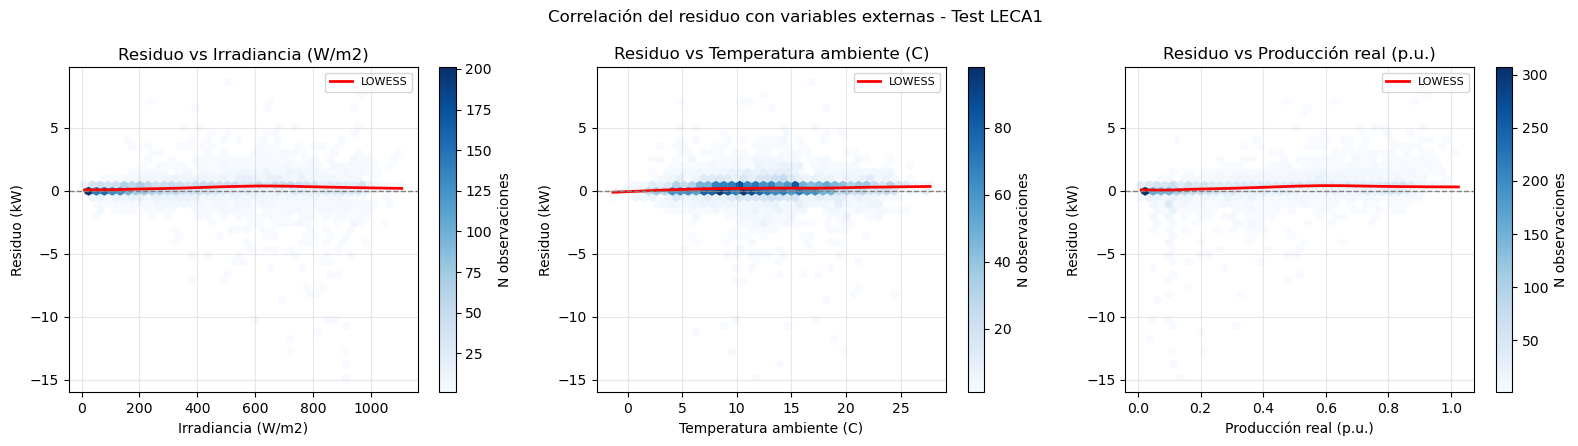

|r| < 0.10 despreciable; |r| > 0.20 información no capturada.


In [15]:
df_sc = df_res[df_res["is_daylight"]].dropna(
    subset=["e_kw", "radiation", "T_ambiente", "power_pu"]
).copy()

variables = {
    "radiation":  "Irradiancia (W/m2)",
    "T_ambiente": "Temperatura ambiente (C)",
    "power_pu":   "Producción real (p.u.)",
}

print("{:<30}  {:>10}  {:>13}  {:>13}".format(
      "Variable", "Pearson r", "p-valor", "Spearman rho"))
print("-" * 72)
for col, label in variables.items():
    r_p, p_p = stats.pearsonr(df_sc[col], df_sc["e_kw"])
    r_s, _   = stats.spearmanr(df_sc[col], df_sc["e_kw"])
    print("{:<30}  {:>10.4f}  {:>13.4e}  {:>13.4f}".format(label, r_p, p_p, r_s))

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
for ax, (col, xlabel) in zip(axes, variables.items()):
    hb = ax.hexbin(df_sc[col], df_sc["e_kw"], gridsize=40, cmap="Blues",
                   mincnt=1, linewidths=0.2)
    plt.colorbar(hb, ax=ax, label="N observaciones")
    lw_fit = lowess(df_sc["e_kw"].values, df_sc[col].values, frac=0.3, return_sorted=True)
    ax.plot(lw_fit[:, 0], lw_fit[:, 1], "r-", lw=2, label="LOWESS")
    ax.axhline(0, color="gray", linestyle="--", lw=1)
    ax.set_xlabel(xlabel); ax.set_ylabel("Residuo (kW)")
    ax.set_title("Residuo vs {}".format(xlabel))
    ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Correlación del residuo con variables externas - Test LECA1", fontsize=12)
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residuo_correlacion.png", dpi=150, bbox_inches="tight")
plt.show()
print("|r| < 0.10 despreciable; |r| > 0.20 información no capturada.")


### 13. Monitor operativo: detector de anomalias persistentes
Detecta periodos con producción real inferior al 85% de lo esperado
de forma sostenida durante al menos 24 horas.


Umbral: producción real < 85% de lo esperado durante >= 24h
Periodos con alerta: 644 registros
Error relativo medio en alertas: -19.68%


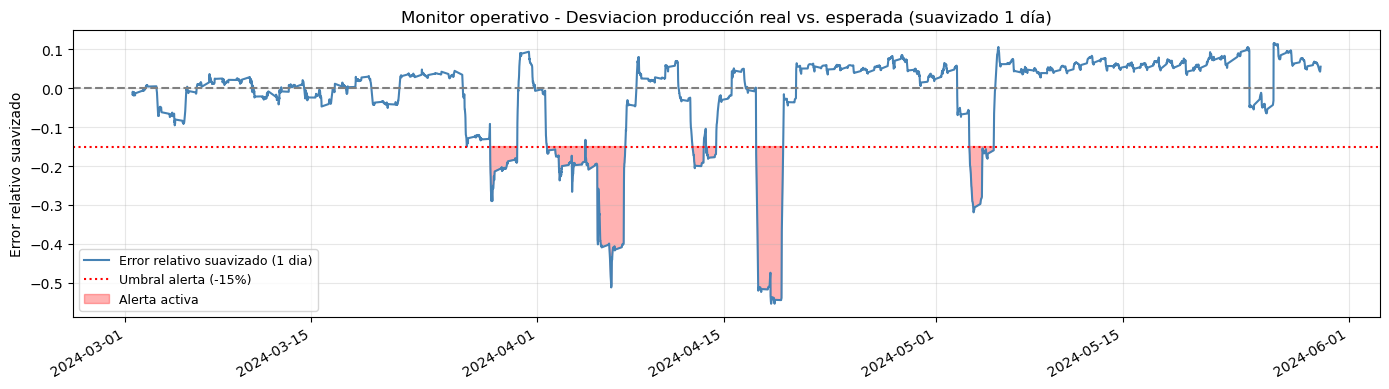

In [16]:
UMBRAL_ALERTA_PCT = 0.15
VENTANA_SUAVIZADO = 96  # 1 dia

df_monitor = df_res[df_res["is_daylight"]].copy().sort_values("timestamp")
df_monitor["e_rel_smooth"] = df_monitor["e_rel"].rolling(
    window=VENTANA_SUAVIZADO, center=False, min_periods=24
).mean()
df_monitor["alerta"] = df_monitor["e_rel_smooth"] < -UMBRAL_ALERTA_PCT

alertas = df_monitor[df_monitor["alerta"]]
print("Umbral: producción real < {:.0f}% de lo esperado durante >= {}h".format(
      (1-UMBRAL_ALERTA_PCT)*100, VENTANA_SUAVIZADO//4))
print("Periodos con alerta: {:,} registros".format(len(alertas)))
if len(alertas) > 0:
    print("Error relativo medio en alertas: {:.2%}".format(alertas["e_rel"].mean()))

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(df_monitor["timestamp"], df_monitor["e_rel_smooth"],
        color=BLUE, lw=1.5, label="Error relativo suavizado (1 dia)")
ax.axhline(0, color="gray", linestyle="--")
ax.axhline(-UMBRAL_ALERTA_PCT, color="red", linestyle=":", lw=1.5,
           label="Umbral alerta ({:.0%})".format(-UMBRAL_ALERTA_PCT))
if len(alertas) > 0:
    ax.fill_between(df_monitor["timestamp"], -UMBRAL_ALERTA_PCT,
        df_monitor["e_rel_smooth"],
        where=df_monitor["alerta"], color="red", alpha=0.3, label="Alerta activa")
ax.set_title("Monitor operativo - Desviacion producción real vs. esperada (suavizado 1 día)")
ax.set_ylabel("Error relativo suavizado")
ax.legend(fontsize=9); ax.grid(alpha=0.3)
fig.autofmt_xdate(); plt.tight_layout()
plt.savefig(RESULTS_DIR / "monitor_operativo.png", dpi=150, bbox_inches="tight")
plt.show()


### 14. Clasificación y zoom de episodios anómalos


,inicio,fin,duracion_horas,e_rel_medio,tipo
bloque,,,,,
2,2024-03-26 16:45:00,2024-03-26 16:45:00,0.25,-0.633,"Esporádica (nube, sombra)"
4,2024-03-28 11:00:00,2024-03-30 11:30:00,23.75,-0.129,Persistente (posible fallo/suciedad)
6,2024-04-01 17:15:00,2024-04-04 14:30:00,34.00,-0.133,Persistente (posible fallo/suciedad)
8,2024-04-04 15:00:00,2024-04-07 14:45:00,36.75,-0.297,Persistente (posible fallo/suciedad)
10,2024-04-12 15:45:00,2024-04-13 12:00:00,9.25,-0.023,Persistente (posible fallo/suciedad)
12,2024-04-13 16:15:00,2024-04-14 10:30:00,7.25,-0.105,Persistente (posible fallo/suciedad)
14,2024-04-17 10:45:00,2024-04-19 11:15:00,26.50,-0.388,Persistente (posible fallo/suciedad)
16,2024-05-03 11:30:00,2024-05-05 07:15:00,23.25,-0.077,Persistente (posible fallo/suciedad)



Total: 8 | Persistentes (>=2h): 7 | Esporádicas: 1


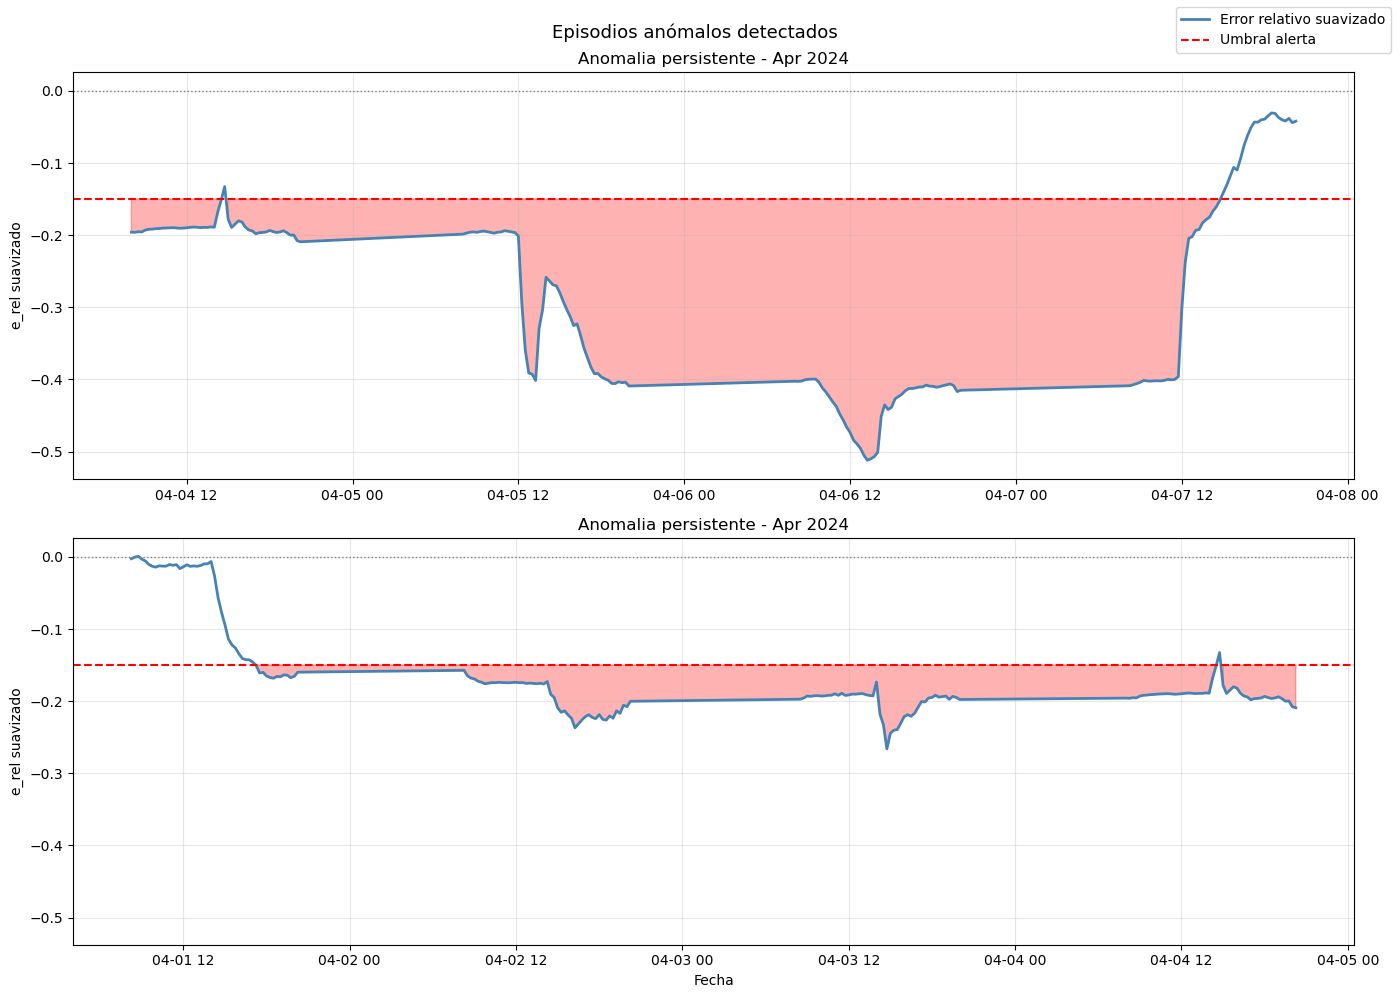

In [20]:
MIN_DURACION_H = 2

df_monitor["alerta_int"] = df_monitor["alerta"].astype(int)
df_monitor["bloque"]     = (df_monitor["alerta_int"].diff() != 0).cumsum()

bloques = df_monitor[df_monitor["alerta"]].groupby("bloque").agg(
    inicio=(        "timestamp", "min"),
    fin=(           "timestamp", "max"),
    duracion_pasos=("timestamp", "count"),
    e_rel_medio=(   "e_rel",     "mean"),
)
bloques["duracion_horas"] = bloques["duracion_pasos"] * 0.25
bloques["tipo"] = bloques["duracion_horas"].apply(
    lambda h: "Persistente (posible fallo/suciedad)"
              if h >= MIN_DURACION_H else "Esporádica (nube, sombra)"
)

if len(bloques) > 0:
    display(bloques[["inicio", "fin", "duracion_horas", "e_rel_medio", "tipo"]].round(3))
    n_pers = bloques["tipo"].str.startswith("Persistente").sum()
    n_espo = len(bloques) - n_pers
    print("\nTotal: {} | Persistentes (>={}h): {} | Esporádicas: {}".format(
          len(bloques), MIN_DURACION_H, n_pers, n_espo))
else:
    print("No se detectaron anomalias en el periodo de test.")

persistentes = bloques[bloques["tipo"].str.startswith("Persistente")]
if len(persistentes) > 0:
    top2 = persistentes.nlargest(min(2, len(persistentes)), "duracion_horas")
    df_mon_idx = df_monitor.set_index("timestamp").sort_index()
    fig, axes = plt.subplots(len(top2), 1,
                             figsize=(14, 5 * len(top2)), sharey=True)
    if len(top2) == 1:
        axes = [axes]
    for ax, (_, row) in zip(axes, top2.iterrows()):
        inicio = str(row["inicio"].date())
        fin    = str(row["fin"].date())
        titulo = "Anomalia persistente - {}".format(row["inicio"].strftime("%b %Y"))
        sub    = df_mon_idx.loc[inicio:fin]
        ax.plot(sub.index, sub["e_rel_smooth"], color=BLUE, lw=2,
                label="Error relativo suavizado")
        ax.axhline(-UMBRAL_ALERTA_PCT, color="red", linestyle="--", lw=1.5,
                   label="Umbral alerta")
        ax.axhline(0, color="gray", linestyle=":", lw=1)
        ax.fill_between(sub.index, sub["e_rel_smooth"], -UMBRAL_ALERTA_PCT,
                        where=sub["e_rel_smooth"] < -UMBRAL_ALERTA_PCT,
                        color="red", alpha=0.3)
        ax.set_title(titulo); ax.set_ylabel("e_rel suavizado"); ax.grid(alpha=0.3)
    axes[-1].set_xlabel("Fecha")
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.suptitle("Episodios anómalos detectados", fontsize=13)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "anomalias_zoom.png", dpi=150, bbox_inches="tight")
    plt.show()


### 15. Perfil diario: dia anómalo frente a día normal


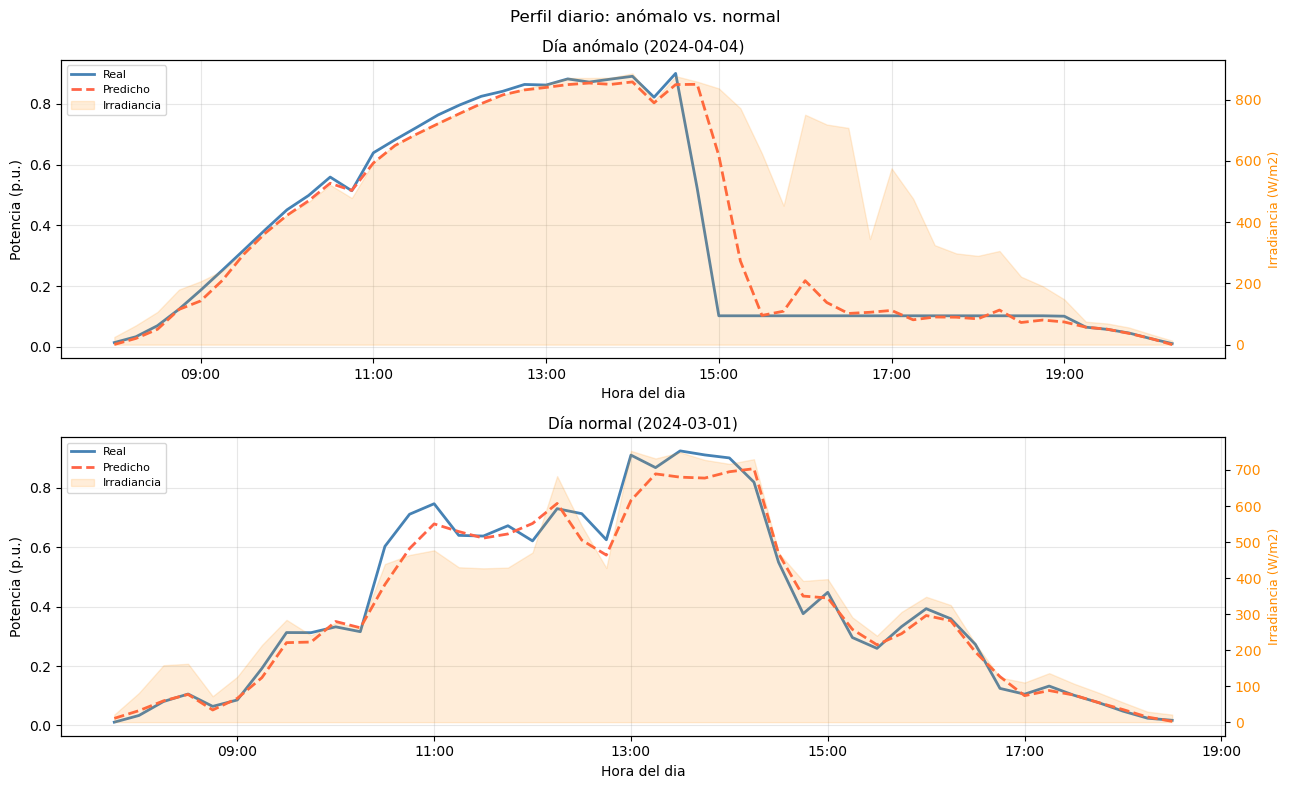

In [21]:
if len(persistentes) > 0:
    df_mon_idx = df_monitor.set_index("timestamp").sort_index()
    dia_anom = persistentes.nlargest(1, "duracion_horas").iloc[0]["inicio"].date()
    fechas_alerta = set(pd.to_datetime(bloques["inicio"]).dt.date)
    fechas_disp   = sorted(set(df_mon_idx.index.date))
    dia_normal    = next((d for d in fechas_disp if d not in fechas_alerta), fechas_disp[0])

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)

    for ax, df_d, titulo in [
        (axes[0], df_mon_idx[df_mon_idx.index.date == dia_anom],
         "Día anómalo ({})".format(dia_anom)),
        (axes[1], df_mon_idx[df_mon_idx.index.date == dia_normal],
         "Día normal ({})".format(dia_normal)),
    ]:
        # Eje principal: potencia
        ax.plot(df_d.index, df_d["power_pu"], label="Real",
                lw=2, color=BLUE)
        ax.plot(df_d.index, df_d["y_pred"], label="Predicho",
                lw=2, color=RED, linestyle="--")

        # Eje secundario: irradiancia
        ax2 = ax.twinx()
        ax2.fill_between(df_d.index, df_d["radiation"],
                         alpha=0.15, color=ORANGE, label="Irradiancia")
        ax2.set_ylabel("Irradiancia (W/m2)", color=ORANGE, fontsize=9)
        ax2.tick_params(axis="y", labelcolor=ORANGE)

        # Formato del eje X con horas legibles
        import matplotlib.dates as mdates
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
        plt.setp(ax.xaxis.get_majorticklabels(), rotation=0, ha="center")

        ax.set_title(titulo, fontsize=11)
        ax.set_ylabel("Potencia (p.u.)")
        ax.set_xlabel("Hora del dia")
        ax.grid(alpha=0.3)

        # Leyenda unificada con la irradiancia
        lines1, labels1 = ax.get_legend_handles_labels()
        lines2, labels2 = ax2.get_legend_handles_labels()
        ax.legend(lines1 + lines2, labels1 + labels2,
                  loc="upper left", fontsize=8)

    plt.suptitle("Perfil diario: anómalo vs. normal", fontsize=12)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "perfil_anomalo_vs_normal.png",
                dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("Sin anomalias persistentes disponibles para comparar.")


### 16. Guardado de resultados y metricas finales


In [ ]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df_res.to_csv(       RESULTS_DIR / "residuos_test.csv",        index=False)
daily.to_csv(        RESULTS_DIR / "residuos_diarios.csv",     index=False)
season_stats.to_csv( RESULTS_DIR / "residuos_estacionales.csv")

# Exportar tabla de anomalias detectadas
if len(bloques) > 0:
    bloques_export = bloques[[
        "inicio", "fin", "duracion_horas", "e_rel_medio", "tipo"
    ]].copy()
    bloques_export.to_csv(RESULTS_DIR / "anomalias_detectadas.csv")
    print("Tabla de anomalias exportada: data/results/anomalias_detectadas.csv")
    print("  {} episodios detectados".format(len(bloques)))
else:
    print("Sin anomalias detectadas: no se genera tabla.")

print("\nTablas de residuos guardadas en data/results/:")
for f in ["residuos_test.csv", "residuos_diarios.csv", "residuos_estacionales.csv"]:
    print("  {}".format(f))

df_day_f = df_res[df_res["is_daylight"]]
print("\nMetricas finales del residuo (horas de produccion):")
print("  Bias medio (kW):        {:+.4f}".format(df_day_f["e_kw"].mean()))
print("  MAE medio (kW):         {:.4f}".format(df_day_f["e_abs_kw"].mean()))
print("  RMSE (kW):              {:.4f}".format(float(np.sqrt((df_day_f["e_kw"]**2).mean()))))
print("  Error relativo medio:   {:.2%}".format(df_day_f["e_rel"].mean()))
print("  Skewness:               {:.4f}".format(stats.skew(df_day_f["e_kw"])))
print("  Curtosis:               {:.4f}".format(stats.kurtosis(df_day_f["e_kw"])))
print("  Registros con |e|>1kW:  {:.1%}".format((df_day_f["e_abs_kw"]>1).mean()))
print("  Registros con |e|>2kW:  {:.1%}".format((df_day_f["e_abs_kw"]>2).mean()))


## Conclusiones del Notebook 10

**Caracterización estadística del residuo:**
- La distribución del error es aproximadamente simétrica con colas pesadas
(curtosis > 1),lo que indica una mayor frecuencia de errores extremos respecto a     una distribución normal.
- El test de Ljung-Box detecta autocorrelación significativa a corto plazo,    sugiriendo que el modelo no captura completamente toda la dinámica temporal del sistema. La incorporación de *lags* adicionales o modelos específicos de series temporales podría reducir parcialmente este componente residual.
- El error acumulado muestra una deriva positiva progresiva, coherente con el bias positivo observado previamente sobre LECA1.

**Monitorización operativa:**
- El detector identifica episodios prolongados en los que la producción real permanece por debajo del valor esperado definido por el modelo.
- Parte de las anomalías detectadas presentan persistencia temporal, lo que podría estar asociado tanto a fenómenos operativos de la planta como a condiciones meteorológicas no representadas adecuadamente por las variables de entrada.
- El perfil diario observado durante algunos episodios anómalos muestra reducciones sistemáticas de producción en las horas centrales del día, un comportamiento potencialmente compatible con pérdidas temporales de eficiencia o efectos de sombreado.

**Valor práctico:**
- Los resultados sugieren que los residuales del modelo podrían utilizarse como señal complementaria para tareas de monitorización y detección temprana de anomalías.
- El umbral de detección y la ventana de suavizado utilizados en este trabajo constituyen parámetros heurísticos y deberían ajustarse y validarse específicamente para cada instalación y contexto operativo.
- Aunque el enfoque muestra potencial para integrarse en sistemas de supervisión energética, sería necesaria una validación adicional con eventos reales etiquetados antes de considerar su despliegue operativo.
